In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re


/people/boufouss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
data = pd.read_csv("../data/concept_net.csv")

## Observation

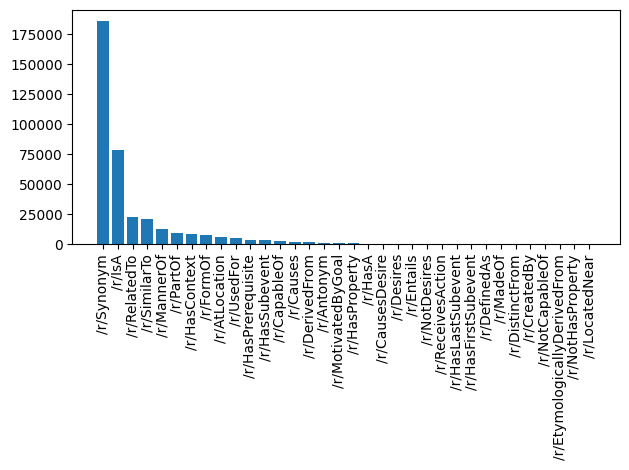

In [3]:
counts = data["relation"].value_counts(sort=True)
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [4]:
counts

relation
/r/Synonym                      185713
/r/IsA                           78236
/r/RelatedTo                     23146
/r/SimilarTo                     21227
/r/MannerOf                      12660
/r/PartOf                         9346
/r/HasContext                     9032
/r/FormOf                         7886
/r/AtLocation                     5811
/r/UsedFor                        5317
/r/HasPrerequisite                3513
/r/HasSubevent                    3417
/r/CapableOf                      2603
/r/Causes                         2235
/r/DerivedFrom                    2006
/r/Antonym                        1369
/r/MotivatedByGoal                1110
/r/HasProperty                     830
/r/HasA                            588
/r/CausesDesire                    566
/r/Desires                         508
/r/Entails                         405
/r/NotDesires                      390
/r/ReceivesAction                  332
/r/HasLastSubevent                 287
/r/HasFirstSubev

In [5]:
data.loc[data["relation"]=="/r/LocatedNear"]
# Changer LocatedNear en AtLocation

,id,relation,head,tail,weight
119926,119926,/r/LocatedNear,/c/en/chair,/c/en/table,2.0
119927,119927,/r/LocatedNear,/c/en/shore,/c/en/ocean,2.0


In [6]:
# Changer les relations de la forme NotRel en Rel, et en mettant 'not_' devant le tail

In [7]:
data.loc[data["relation"]=="/r/EtymologicallyDerivedFrom"][:5]
# Supprimer cette relation


,id,relation,head,tail,weight
15852,15852,/r/EtymologicallyDerivedFrom,/c/en/bas_relief,/c/fr/bas_relief,2.0
15853,15853,/r/EtymologicallyDerivedFrom,/c/en/basque,/c/fr/basque,2.0
15854,15854,/r/EtymologicallyDerivedFrom,/c/en/beaux_arts,/c/fr/beaux_arts,2.0
15855,15855,/r/EtymologicallyDerivedFrom,/c/en/brie,/c/fr/brie,2.0
15856,15856,/r/EtymologicallyDerivedFrom,/c/en/champagne,/c/fr/champagne,2.0


In [8]:
data.loc[data["relation"]=="/r/HasContext"].sort_values(by="weight", ascending = False)

,id,relation,head,tail,weight
33376,33376,/r/HasContext,/c/fr/états_généraux/n,/c/fr/histoire,3.464
33375,33375,/r/HasContext,/c/fr/états_généraux/n,/c/fr/france,3.464
29213,29213,/r/HasContext,/c/en/middle_earth/n,/c/en/fiction,3.464
31956,31956,/r/HasContext,/c/en/supreme_court/n/wn/law,/c/en/law/n/wn/group,3.464
30627,30627,/r/HasContext,/c/en/rabbi/n/wn/hebrew,/c/en/hebrew/n/wn/communication,3.464
...,...,...,...,...,...
27363,27363,/r/HasContext,/c/en/first/a/wn/music,/c/en/music/n/wn/communication,2.000
27364,27364,/r/HasContext,/c/en/first/n/wn/communication,/c/en/united_kingdom/n/wn/location,2.000
27365,27365,/r/HasContext,/c/en/first_amendment/n/wn/law,/c/en/law/n/wn/group,2.000
27366,27366,/r/HasContext,/c/en/first_baseman/n/wn/baseball,/c/en/baseball/n/wn/act,2.000


## Pre-processing

### Relations

In [9]:
rel_del = ['/r/EtymologicallyDerivedFrom']
data = data[~data['relation'].isin(rel_del)]

In [10]:
mask_not = data['relation'].str.startswith('/r/Not', na=False)

data.loc[mask_not, 'tail'] = data.loc[mask_not, 'tail'].apply(
    lambda x: '/'.join(
        [part if i != 3 else 'not_' + part for i, part in enumerate(str(x).split('/'))]
    )
)

data.loc[mask_not, 'relation'] = data.loc[mask_not, 'relation'].str.replace('/r/Not', '/r/')

data[mask_not]

,id,relation,head,tail,weight
133805,133805,/r/CapableOf,/c/en/americans,/c/en/not_eat_cats,2.000
133806,133806,/r/CapableOf,/c/en/artichoke_hearts,/c/en/not_beat,2.000
133807,133807,/r/CapableOf,/c/en/atheists,/c/en/not_believe_god_exists,2.828
133808,133808,/r/CapableOf,/c/en/atheists,/c/en/not_believe_in_god,6.325
133809,133809,/r/CapableOf,/c/en/cats,/c/en/not_like_water,2.000
...,...,...,...,...,...
134232,134232,/r/HasProperty,/c/en/smoking,/c/en/not_good_for_health,3.464
134233,134233,/r/HasProperty,/c/en/woman_workaholic,/c/en/not_frivolous_and_flighty,2.000
134234,134234,/r/HasProperty,/c/en/world,/c/en/not_flat,2.000
134235,134235,/r/HasProperty,/c/en/world,/c/en/not_round,2.000


In [11]:
mapp_rename = {
    '/r/LocatedNear': '/r/AtLocation',
    '/r/HasLastSubevent' : '/r/HasSubevent',
    '/r/HasFirstSubevent' : '/r/HasSubevent'
}

data['relation'] = data['relation'].replace(mapp_rename)

In [13]:
symetric_rel = ['/r/Synonym', '/r/RelatedTo', '/r/SimilarTo', '/r/Antonym', '/r/DistinctFrom']

df_sym = data[data['relation'].isin(symetric_rel)].copy()
df_sym = df_sym.rename(columns={'head': 'tail', 'tail': 'head'})

data = pd.concat([data, df_sym], ignore_index=True)

data = data.drop_duplicates()

In [14]:
data['relation'] = data['relation'].str.removeprefix('/r/')

In [15]:
data = data.drop(columns=["id"])

### Entités

In [16]:
data['head'] = data['head'].str.removeprefix('/c/')
data['tail'] = data['tail'].str.removeprefix('/c/')

In [17]:
mask_en_fr = data['head'].str.startswith('en/', na=False) & data['tail'].str.startswith('fr/', na=False)

mask_fr_en = data['head'].str.startswith('fr/', na=False) & data['tail'].str.startswith('en/', na=False)

data_lang_asymetry = data[mask_en_fr | mask_fr_en]

data_lang_symetry = data[~(mask_en_fr | mask_fr_en)]

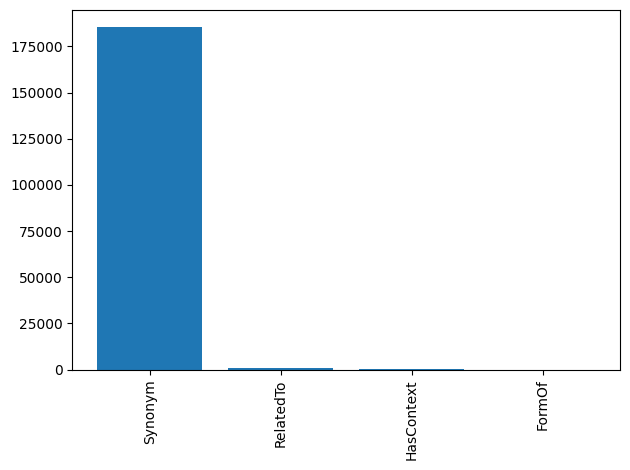

In [18]:
counts = data_lang_asymetry["relation"].value_counts(sort=True)
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

La relation Synonym semble servir pour la traduction. On va faire 3 csv, un pour 'en', un autre pour fr et le dernier pour la traduction.

In [19]:
data_en = data_lang_symetry[data_lang_symetry['head'].str.startswith('en/', na=False)].copy()
data_fr = data_lang_symetry[data_lang_symetry['head'].str.startswith('fr/', na=False)].copy()

data_en['head'] = data_en['head'].str.removeprefix('en/')
data_en['tail'] = data_en['tail'].str.removeprefix('en/')

data_fr['head'] = data_fr['head'].str.removeprefix('fr/')
data_fr['tail'] = data_fr['tail'].str.removeprefix('fr/')

In [20]:
data_translate = data_lang_asymetry.copy()

In [21]:
data_translate.shape[0] + data_en.shape[0] + data_fr.shape[0] == data.shape[0]
# pour verifier si le partage s'est bien fait

True

In [22]:
data_fr["relation"].unique()

array(['Antonym', 'DerivedFrom', 'FormOf', 'HasContext', 'IsA', 'MadeOf',
       'MotivatedByGoal', 'PartOf', 'RelatedTo', 'SimilarTo', 'Synonym',
       'UsedFor'], dtype=object)

In [23]:
data_en["relation"].unique()

array(['Antonym', 'AtLocation', 'CapableOf', 'Causes', 'CausesDesire',
       'CreatedBy', 'DefinedAs', 'DerivedFrom', 'Desires', 'DistinctFrom',
       'Entails', 'FormOf', 'HasA', 'HasContext', 'HasSubevent',
       'HasPrerequisite', 'HasProperty', 'IsA', 'MadeOf', 'MannerOf',
       'MotivatedByGoal', 'PartOf', 'ReceivesAction', 'RelatedTo',
       'SimilarTo', 'Synonym', 'UsedFor'], dtype=object)

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

def lemmatize_entity(text):
    doc = nlp(text)
    keep = [
        t for t in doc
        if t.pos_ not in {"DET", "ADP", "CCONJ", "SCONJ", "PUNCT", "PART", "AUX"}
        or t.lemma_.lower() in {"not", "no", "never"}
    ]
    if not keep:
        keep = list(doc)
    lemmas = [t.lemma_.lower() for t in keep]
    return "_".join(lemmas)

def head_word(x):
    return str(x).split('/')[0].replace('_', ' ')

uniques = pd.unique(pd.concat([
    data_en['head'].map(head_word),
    data_en['tail'].map(head_word),
]))

lemma_map = {w: lemmatize_entity(w) for w in uniques}

def lemmatize_prefix(x):
    word, sep, suffix = str(x).partition('/')
    return lemma_map[word.replace('_', ' ')] + sep + suffix

data_en['head'] = data_en['head'].apply(lemmatize_prefix)
data_en['tail'] = data_en['tail'].apply(lemmatize_prefix)

data_en = data_en.drop_duplicates(subset=['relation', 'head', 'tail'])
print("après lemmatisation + dédup :", data_en.shape)
data_en[['relation', 'head', 'tail']].head(10)


172121 préfixes uniques à lemmatiser
après lemmatisation + dédup : (382554, 4)


,relation,head,tail
0,Antonym,a.m/r,p.m
1,Antonym,ability/n,inability
2,Antonym,abnormality/n,normality
3,Antonym,above,below
4,Antonym,absolute/a,relative
5,Antonym,accelerate/v,decelerate
6,Antonym,acceptable/a,unacceptable
7,Antonym,accessible/a,inaccessible
8,Antonym,activate/v,deactivate
9,Antonym,activity/n,passivity


## Save

In [39]:
data_en['head_word'] = data_en['head'].str.split('/', n=1).str[0]
data_en['tail_word'] = data_en['tail'].str.split('/', n=1).str[0]


In [41]:
data_fr.to_csv("../data/concept_net_fr.csv")
data_en.to_csv("../data/concept_net_en.csv")
data_translate.to_csv("../data/concept_net_translate.csv")